Install Packages

In [18]:

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install timm
!pip install grad-cam
!pip install pandas matplotlib scikit-learn pillow

Looking in indexes: https://download.pytorch.org/whl/cpu


Imports & Device

In [19]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from PIL import Image
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt

import timm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# CPU setup
device = torch.device("cpu")
torch.set_num_threads(4)
print("Using device:", device)

Using device: cpu


Dataset Class

In [20]:
class APTOSDataset(Dataset):
    def __init__(self, csv_path, image_folder, transform=None):
        self.df = pd.read_csv(csv_path)
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]["id_code"]
        label = self.df.iloc[idx]["diagnosis"]
        img_path = os.path.join(self.image_folder, img_id + ".png")
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

Transforms

In [28]:
transform = transforms.Compose([
    transforms.Resize((224,224)),  # CPU-friendly
    transforms.ToTensor(),
])

Load Dataset

In [29]:
dataset = APTOSDataset("C:\\Users\\DELL\\Downloads\\aptos2019-blindness-detection\\train.csv", "C:\\Users\\DELL\\Downloads\\aptos2019-blindness-detection\\train_images", transform)

# Split into train/validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

Weighted Focal Loss

In [30]:
class_counts = Counter(dataset.df["diagnosis"])
class_counts = torch.tensor([class_counts[i] for i in range(5)], dtype=torch.float)
weights = 1.0 / class_counts
weights = weights / weights.sum()
weights = weights.to(device)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=alpha)

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss

criterion = FocalLoss(alpha=weights, gamma=2)

Model

In [31]:
model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=5)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Training Loop with Live Plot

Epoch [1/3] Train Loss: 0.5632 Val Acc: 0.7462 QWK: 0.7357
Epoch [2/3] Train Loss: 0.4782 Val Acc: 0.7462 QWK: 0.5759
Epoch [3/3] Train Loss: 0.4374 Val Acc: 0.7517 QWK: 0.7324


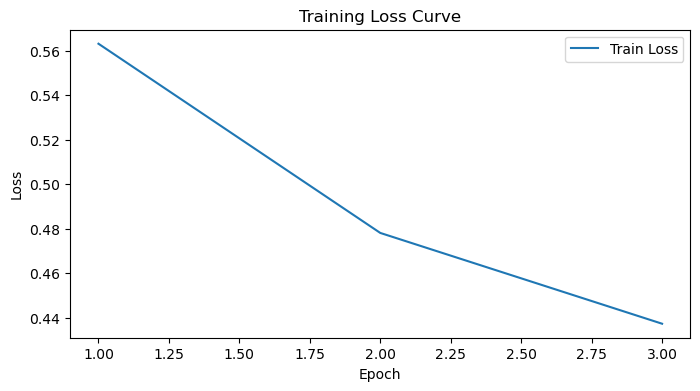

In [32]:
num_epochs = 3  # Start small for CPU
train_losses = []
val_accs = []
qwk_scores = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_losses.append(train_loss/len(train_loader))

    # Validation
    model.eval()
    all_preds = []
    all_labels = []

    for i in range(len(val_dataset)):
        image, label = val_dataset[i]
        with torch.no_grad():
            output = model(image.unsqueeze(0).to(device))
            pred = torch.argmax(output, dim=1).item()
        all_preds.append(pred)
        all_labels.append(label)

    val_acc = np.mean(np.array(all_preds) == np.array(all_labels))
    qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    val_accs.append(val_acc)
    qwk_scores.append(qwk)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_losses[-1]:.4f} Val Acc: {val_acc:.4f} QWK: {qwk:.4f}")

# Plot Training Loss
plt.figure(figsize=(8,4))
plt.plot(range(1,num_epochs+1), train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.show()

Grad-CAM Visualization

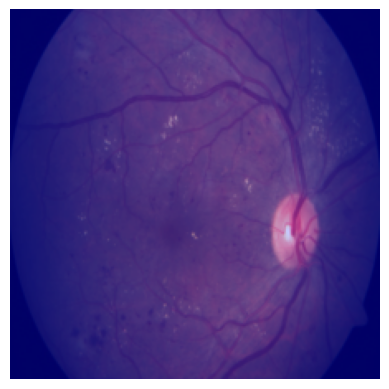

In [36]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

# Reshaping function for ViT
def reshape_transform(tensor):
    # Removing class token
    tensor = tensor[:, 1:, :]
    h = w = int(tensor.shape[1] ** 0.5)
    tensor = tensor.reshape(tensor.size(0), h, w, tensor.size(2))
    tensor = tensor.permute(0, 3, 1, 2)
    return tensor

# Using last transformer block norm layer
target_layer = model.blocks[-1].norm1

cam = GradCAM(
    model=model,
    target_layers=[target_layer],
    reshape_transform=reshape_transform
)

# Example image
image, label = val_dataset[0]
input_tensor = image.unsqueeze(0).to(device)

grayscale_cam = cam(input_tensor=input_tensor)[0]

# Converting tensor image to numpy
rgb_img = image.permute(1, 2, 0).numpy()
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.axis("off")
plt.show()

QWK Score

In [37]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

In [38]:
num_epochs = 10
optimizer = optim.Adam(model.parameters(), lr=5e-5)

Validation Accuracy + QWK Score

In [39]:
from sklearn.metrics import cohen_kappa_score
import numpy as np

def evaluate_model(model, val_loader, device):
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Accuracy
    val_acc = np.mean(all_preds == all_labels)
    
    # Quadratic Weighted Kappa
    qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    
    return val_acc, qwk

In [40]:
val_acc, qwk = evaluate_model(model, val_loader, device)

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"QWK Score: {qwk:.4f}")

Validation Accuracy: 0.7517
QWK Score: 0.7324


Confusion Matrix

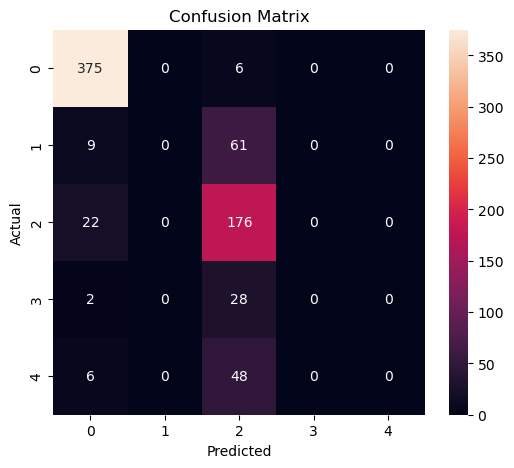

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()